# Machine Learning
### Logistic regression
**Logistic regression** is a probabilistic **linear classifier** that models the probability that a binary target variable $y\in\{0,1\}$ equals $1$ given input features $x\in R^q$. It uses the **logistic** function $\sigma(z)=1/(1+e^{-z})$ to map a linear combination of features $\boldsymbol{w}^⊤\boldsymbol{x}$ to a probability in $(0,1)$.
<br>The (average) **loss** function for $n$ data pairs $(\boldsymbol{x}^{(i)},y^{(i)})$ is Negative Log-Likelihood (Loss) or **cross-entropy**:
<div style="margin:3px">$\mathcal{L}(\boldsymbol{w})=−\frac{1}{n}\sum_i y^{(i)}\cdot log⁡(p^{(i)})+ (1−y^{(i)})\cdot log⁡(1−p^{(i)})$ &nbsp; &nbsp; &nbsp; &nbsp; (1)</div>

where $p^{(i)}=\sigma(\boldsymbol{w}^⊤\boldsymbol{x^{(i)}})$. This $\mathcal{L}(\boldsymbol{w})$ is convex — guaranteed to have a global minimum.
- The column weight vector is $\boldsymbol{w}=[w_0,w_1,...,w_{q-1}]^T$ in which $w_0$ is the **bias**.
- The first element of each vector $\boldsymbol{x}^{(i)}$ (with $q$ elements) is 1 to include *bias*.
<hr>

The **gradient** of loss function in Eq. (1) may be expressed as:
<br>For parameter $w_j$ (where $j=0,1,...,q−1)$:
<div style="margin:3px;">$\frac{\partial{\mathcal{L}}}{\partial{w_j}}=\frac{1}{n}\sum_{i=1}^n (p^{(i)}−y^{(i)})\cdot x_{ij}$
</div>
In vector form (a column vector with $q$ elements):
<div style="margin:3px;">$\nabla_w \mathcal{L}(w)=\frac{1}{n}X^T(\boldsymbol{p}−\boldsymbol{y})$
</div>

where:
- $X$ is $n\times q$ matrix (first column all 1's for bias) such that each row $i$ contains elements of vector $\boldsymbol{x}^{(i)}$.
- $\boldsymbol{p}$ is $n\times 1$ vector of predictions $p^{(i)}$'s
- $\boldsymbol{y}$ is $n\times 1$ vector of true labels $y^{(i)}$'s
<hr>

The **training** algorithm based on **gradient decent** for *logistic regression* will be:
- Initialize $\boldsymbol{w}\leftarrow 0$ (or small random values).
- For $t=1$ to $T$:
  - a. Compute predictions: $p^{(i)}=\sigma(\boldsymbol{w}^⊤\cdot \boldsymbol{x}^{(i)})$ for all $i=1, 2,...,n$.
  - b. Compute gradient: $\nabla \mathcal{L}=\frac{1}{n}X^⊤(\boldsymbol{p}−\boldsymbol{y})$
      - where the prediction vector is: $\boldsymbol{p}=[p^{(1)},..., p^{(n)}]^T$ 
  - c. Update weights: $\boldsymbol{w}\leftarrow \boldsymbol{w} −\alpha \nabla \mathcal{L}$, where $\alpha$ is the learning rate.
  - d. If $\|\nabla \mathcal{L}\|<\epsilon$: break.
- Return $\boldsymbol{w}$.

Here, $T$ is the maximum number of iterations. Also, $\epsilon$ is a small positive number playing the role of **tolerance**.
<hr>

The **prediction** algorithm is to predict the class (label) of a new input vector:
- For new input $\boldsymbol{x}_{new}=[1,x_1,...,x_{q−1}]^T$:
- Compute probability: $p=\sigma(\boldsymbol{w}^T \boldsymbol{x}_{new})=1/(1+exp(-\boldsymbol{w}^T\boldsymbol{x}_{new}))$
- Predict class:
$ y_{predicted} = \begin{cases}
1 & \text{if } p\ge0.5 \\
0 & \text{otherwise}
\end{cases}
$

<hr>

The logistic regression with **regularization**: Here, we modify the loss by an L2 regualrization term:
<div style="margin:3px;">
$\mathcal{L}_{reg}(\boldsymbol{w})=\mathcal{L}(\boldsymbol{w})+\frac{\lambda}{2} \sum_{j=1}^{q-1} w_j^2$, (excluded the bias term $w_0$)
</div>

where $\lambda \ge0$ is the **regularization strength** (controls trade-off between bias and variance). 
- In fact, the second term penalizes large weights, encouraging simpler models.

The **gradient** of logistic regression with L2 regularization becomes:
<div style="margin:3px;">
$\nabla_\boldsymbol{w}\mathcal{L}_{reg}=\frac{1}{n}X^⊤(\boldsymbol{p}−\boldsymbol{y})+\lambda[0,w_1,w_2,...w_{q-1}]^T$
</div>

In summary, the **L2 regularization**:
- Prevents weights from exploding.
- Guarantees a unique solution even with perfect separation.
- Always recommended when $n\le q$.

<hr>

In the following, we implement logistic regression with L2 regularization from scratch. by letting $\lambda=0$, we get the standard logistic regression. The logistic regression is tested by a synthetic datset for binary classification.
<br> As a Bonus, we use the **Iris** dataset with logistic regression. In this case, we redefine the Iris dataset in two classes because logistic regression is a binary classifier.
<hr>

https://github.com/ostad-ai/Machine-Learning
<br> Explanation: https://www.pinterest.com/HamedShahHosseini/Machine-Learning/

In [19]:
# Import required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [120]:
class LogisticRegression:
    
    def __init__(self, learning_rate=0.01, max_iter=1000, 
                  tol=1e-6, reg_lambda=0):
        """
        Logistic Regression classifier with L2 regularization.
        
        Args:
            learning_rate (float): Step size for gradient descent.
            max_iter (int): Maximum number of iterations.
            tol (float): Tolerance for early stopping.
            reg_lambda (float): L2 regularization strength (lambda >= 0).
                                Set to 0 for no regularization.
        """
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.reg_lambda = reg_lambda  # L2 regularization parameter
        self.w = None  # Weight vector [w_0 (bias), w_1, ..., w_d-1]
    
    def _sigmoid(self, z):
        """Numerically stable sigmoid."""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
                        
    def fit(self, X, y):
        """
        Train the model using gradient descent with L2 regularization.
        
        Args:
            X (np.ndarray): data matrix with no bias (n, d-1)
            y (np.ndarray): Binary targets (n,)
        """
        n, d1 = X.shape
        d = d1 + 1  # Include bias term
        X_bias = np.c_[np.ones(n), X]  # Shape: (n, d)
        
        # Initialize weights
        self.w = np.zeros(d)
        
        for i in range(self.max_iter):
            # Forward pass: compute predictions
            z = X_bias @ self.w
            y_pred = self._sigmoid(z)
            
            # Compute base gradient (without regularization)
            errors = y_pred - y
            gradient = X_bias.T @ errors / n  # Shape: (p,)
            
            # Add L2 regularization (skip bias term w[0])
            if self.reg_lambda > 0: 
                gradient[1:] += self.reg_lambda * self.w[1:]  
            
            # Check convergence
            if np.linalg.norm(gradient) < self.tol:
                # print(f"Converged at iteration {i}")
                break
            
            # Update weights
            self.w -= self.learning_rate * gradient
    
    def predict_proba(self, X):
        """Predict probabilities for class 1."""
        n = X.shape[0]
        X_bias = np.c_[np.ones(n), X]
        z = X_bias @ self.w
        return self._sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Predict binary labels."""
        return (self.predict_proba(X) >= threshold).astype(int)

In [122]:
# Example usage
# Generate synthetic data
np.random.seed(42)
n = 100
X = np.random.randn(n, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)  # Linear decision boundary

# Train model with λ values
lambdas = [0.0, 0.001, 0.01, 0.1, 1.0]
for lan in lambdas:
    model = LogisticRegression(learning_rate=0.1, 
                        max_iter=1000,reg_lambda=lan)
    model.fit(X, y)
    # Evaluate
    y_pred = model.predict(X)
    accuracy = np.mean(y_pred == y)
    print(f"Accuracy: {accuracy:.2f} with λ ={lan:.3f}", end=', ')
    print(f" and weights: {model.w}")

Accuracy: 0.99 with λ =0.000,  and weights: [-0.17462947  3.73358795  3.74240946]
Accuracy: 0.99 with λ =0.001,  and weights: [-0.1765916   3.56030397  3.57589032]
Accuracy: 0.99 with λ =0.010,  and weights: [-0.19148006  2.5293498   2.58477427]
Accuracy: 0.95 with λ =0.100,  and weights: [-0.22086813  0.95435664  1.05859837]
Accuracy: 0.80 with λ =1.000,  and weights: [-0.23156665  0.19858909  0.24966297]


<hr style="height:3px; background:lightblue">

# Bonus 
#### Logistic regression for Iris dataset

<hr style="height:3px; background:lightgreen">

### Loading Iris dataset

In [20]:
# Downlaod the iris dataset into a panda dataframe
df=pd.read_csv("https://raw.githubusercontent.com/ostad-ai/Machine-Learning/refs/heads/main/iris.csv")    

In [21]:
df.head()

,Sepal Length,Sepal Width,Petal Length,Petal Width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


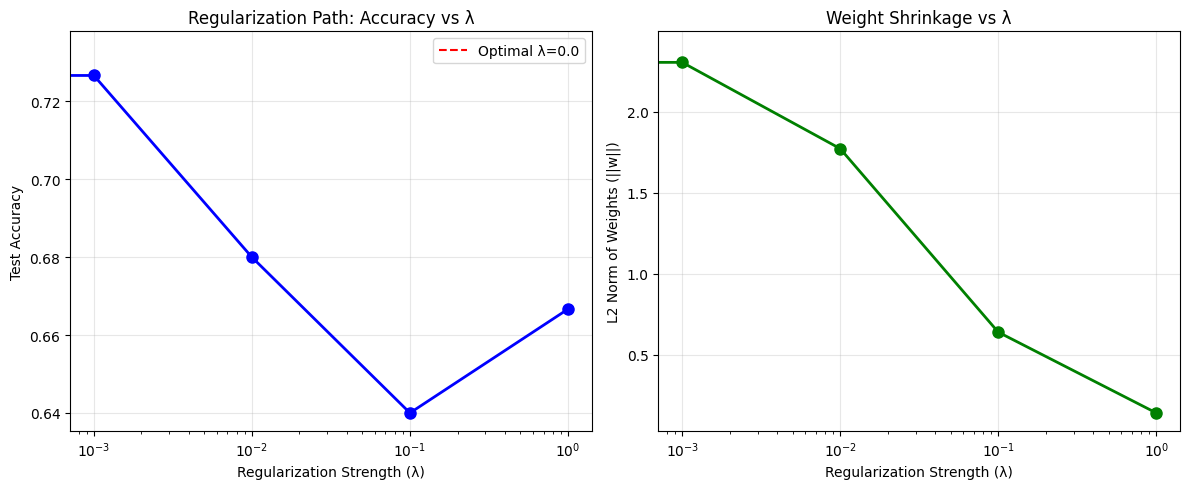

λ	Accuracy	||w|| (non-bias)
-----------------------------------
0.000	0.7333		2.3844
0.001	0.7267		2.3049
0.010	0.6800		1.7718
0.100	0.6400		0.6382
1.000	0.6667		0.1389

Optimal λ: 0.0 → Accuracy: 0.7333


In [115]:
# Example with iris data set
# Get the feature vectors in rows
X_iris=df.values[:,:4].astype('float')
X_iris+=.2*np.random.randn(150,4)
# get the labels
y_iris=df.values[:,4]
# Redefine Iris as a two-class problem 
# y_iris=np.where(y_iris=='Iris-setosa',0,1) # with this: accuracy = 1
y_iris=np.where(y_iris=='Iris-versicolor',0,1)
#-----------------------
# Evaluate
# Test λ values
lambdas = [0.0, 0.001, 0.01, 0.1, 1.0]
accuracies = []
weight_norms = []  # Store ||w|| for non-bias weights

for lam in lambdas:
    model = LogisticRegression(reg_lambda=lam, learning_rate=0.1)
    model.fit(X_iris, y_iris)
    acc = np.mean(model.predict(X_iris) == y_iris)
    accuracies.append(acc)
    
    # Compute L2 norm of NON-BIAS weights (w[1:])
    w_non_bias = model.w[1:]
    weight_norms.append(np.linalg.norm(w_non_bias))

# STEP 2: Plot regularization path
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy vs λ
# Optimal λ
best_idx = np.argmax(accuracies)
plt.subplot(1, 2, 1)
plt.plot(lambdas, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Regularization Strength (λ)')
plt.ylabel('Test Accuracy')
plt.title('Regularization Path: Accuracy vs λ')
plt.grid(True, alpha=0.3)
plt.axvline(x=lambdas[best_idx], color='r', linestyle='--', label=f'Optimal λ={lambdas[best_idx]}')
plt.legend()

# Subplot 2: Weight norm vs λ
plt.subplot(1, 2, 2)
plt.plot(lambdas, weight_norms, 'go-', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Regularization Strength (λ)')
plt.ylabel('L2 Norm of Weights (||w||)')
plt.title('Weight Shrinkage vs λ')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# STEP 3: Print weight analysis
print("λ\tAccuracy\t||w|| (non-bias)")
print("-" * 35)
for lam, acc, norm in zip(lambdas, accuracies, weight_norms):
    print(f"{lam:.3f}\t{acc:.4f}\t\t{norm:.4f}")

# Highlight optimal λ
print(f"\nOptimal λ: {lambdas[best_idx]} → Accuracy: {accuracies[best_idx]:.4f}")